# BTC 5-minute Polymarket bot — turn $300 into $14,000? 🎰
### The viral "free GitHub bot" that bets Bitcoin's last two minutes, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Get_rich_quick%3F: Busted](https://img.shields.io/badge/Get_rich_quick%3F-Busted-8b949e?style=flat-square)

A post goes viral: *"I put in \$300. This bot turned it into \$14,000. I didn't even code it — I grabbed an open-source repo, cleaned it up in a couple of hours, and let it run."* The recipe: on Polymarket's **Bitcoin Up/Down 5-minute** markets, with ~2 minutes left, if BTC has already moved \$70–100, buy the **winning side** while it's quoted **\$0.80–0.99** — *"it's like buying a lottery ticket after they've called the numbers."*

Is it real? Surprisingly, the momentum part **is**. The money part is **not**. This notebook shows why both things are true at once.

> 📓 **Plain-language layer.** Want the *z*-stats, the fair-price algebra and the bankroll maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a safety note.** The advertised repo ships only a wrapper; the engine that signs trades and reads your **wallet private key** lives in a *separate, unpublished* repo. "Completing" it means handing an unaudited program your keys. Don't. Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from btc5m_polymarket import data, strategy as st

HAVE_REAL = data.have_real()
W = data.load_real() if HAVE_REAL else None
print("real BTC tape cache present:", HAVE_REAL,
      "| windows:", (0 if W is None else len(W)))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2026-05-06 → 2026-06-20', 'days': 45, 'windows': 12959, 'p_up': 49.5, 'flat': 0.12, 'btc_lo': 59207, 'btc_hi': 82761, 'med_move': 32, 'p90_move': 109, 'w30': 89.1, 'n30': 6802, 'z30': 64.5, 'w50': 92.9, 'n50': 4322, 'w70': 94.8, 'n70': 2759, 'frac70': 21.3, 'z70': 47.0, 'w85': 96.3, 'w100': 96.5, 'n100': 1533, 'w150': 98.6, 'w70_1m': 98.2, 'w100_1m': 99.3, 'mc_fair_p': 0.948, 'mc_fair_target': 1.07, 'mc_fair_ruin': 39.7, 'mc_fair_med': 4.06, 'mc_over_ruin': 99.3, 'mc_pitch_target': 100.0, 'mc_pitch_med': 14668, 'mc_yaml_med': 2853, 'syn': [(30, 0.98, 0.98), (45, 0.942, 0.943), (60, 0.913, 0.913)], 'live_n': 32, 'live_all_w': 65.6, 'live_all_p': 76.4, 'live_all_edge': -0.108, 'live_sig_n': 4, 'live_sig_p': 0.97}


real BTC tape cache present: True | windows: 12959


## The answer first

| Question | Answer |
|---|---|
| Does BTC keep going the way it just moved? | **Yes — really.** Once it has moved \$70 with 2 minutes left, it closes that way **~95%** of the time (2,759 cases). That's not a coin; it's a genuine effect. |
| So is it free money? | **No.** The market sees the same move. It quotes that winning side at **\$0.95–0.99** — *exactly* its true odds. You pay full price; there's nothing left over. |
| The pitch says "buy at \$0.80." | **That price isn't there when the move is real.** A cheap \$0.80 quote only exists when the outcome is genuinely *uncertain* — i.e. when the win-rate is \$0.80 too. |
| Then how did \$300 become \$14,000? | **One lucky survivor.** Bet half your stack each round on a 95% favourite and you usually grind up… until the 1-in-20 wipes you. A few people moon; most bust. The poster is the one you hear from. |

> The momentum is real. The edge is already in the price. The jackpot is a martingale's lucky survivor.

## 1 · The claim

> *"Enter ~2 minutes before the round closes. Check Bitcoin has already moved \$70–100 in the interval. Always trade **with** the move. Buy that side at \$0.80–0.99 — a few minutes later it settles at \$1. Like buying a lottery ticket after they've called the numbers."*

Polymarket's **BTC Up/Down 5-minute** market resolves **Up** if BTC's price at the close of the 5-minute window is ≥ its price at the open (resolution via the Chainlink BTC/USD feed). A share pays **\$1** if you're right, **\$0** if you're wrong. The claim is that near the close the outcome is *nearly decided*, so the favoured side at \$0.80–0.99 is almost-free money.

## 2 · So what?

Two very different things are bundled in the pitch, and the trick is that the **first is true**. (1) *Does a fresh \$70 move tend to stick for two more minutes?* If yes, there's a real predictive signal. (2) *Can you buy it for less than it's worth?* Only if the market mis-prices that signal. A binary share that wins with probability **w**, bought at price **p**, earns exactly **w − p** per share. So the whole game reduces to one number: **is w bigger than the p you actually pay?** We can measure both.

## 3 · How would we even know?

We rebuild Polymarket's object from real Bitcoin data: **45 days** of 1-minute BTC prices folded into **12,959** non-overlapping 5-minute windows. For each window we know the open, the price with **2 minutes left**, and the close — everything the strategy sees, plus the answer.

1. **Measure the momentum (w).** Among windows that already moved ≥ \$70 with 2 minutes left, how often does the close finish on the move's side?
2. **Find the price (p).** A read-only paper-trade bot (no key, no money) captured the **real Polymarket ask** of the favoured side at the 2-minute mark on live markets.
3. **Play out the story.** Simulate the \$300→\$14,000 dream thousands of times at the measured win-rate to see who actually gets there.

## 4 · The teardown — let's actually look

**First: is the momentum real?** Win-rate of the favoured side as we demand a bigger head-start at the 2-minute mark.

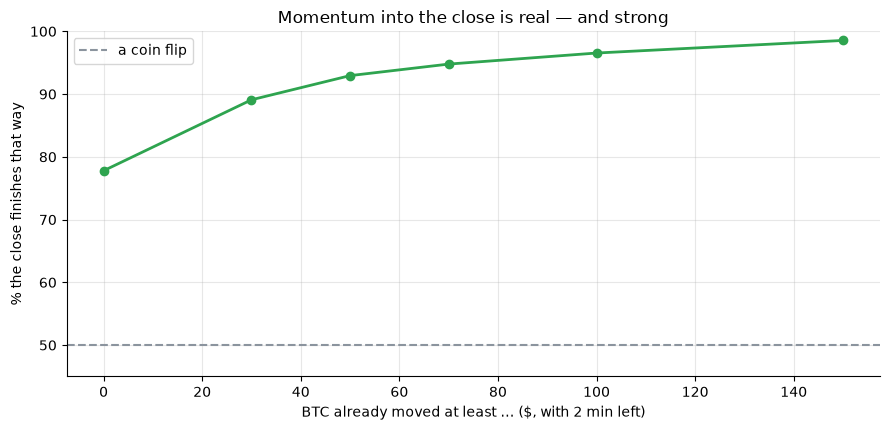

win-rate by head-start: ['78%', '89%', '93%', '95%', '97%', '99%']


In [2]:
Ds = [0, 30, 50, 70, 100, 150]
if HAVE_REAL:
    ws = [st.continuation(W, d)['w']*100 for d in Ds]
else:
    ws = [77.8, R['w30'], R['w50'], R['w70'], R['w100'], R['w150']]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(Ds, ws, 'o-', c=GREEN, lw=2)
ax.axhline(50, ls='--', c=GREY, label='a coin flip')
ax.set_ylim(45, 100); ax.set_xlabel('BTC already moved at least … ($, with 2 min left)')
ax.set_ylabel('% the close finishes that way')
ax.set_title('Momentum into the close is real — and strong'); ax.legend()
plt.tight_layout(); plt.show()
print('win-rate by head-start:', [f'{w:.0f}%' for w in ws])

With **no** filter the close follows the 3-minute drift ~78% of the time already; demand a **\$70** head-start and it's **~95%** (2,759 windows), at **\$100** ~96%. **The signal is genuine** — bigger move, more follow-through. So far the pitch looks right.

**Now the catch: what does the market charge for it?** Here is a real snapshot from the live capture — a window with a clear move and ~70 seconds left:

| | |
|---|---|
| BTC move in the window | **−\$30** (Down is winning) |
| Polymarket ask, *Down* (the favourite) | **\$0.97** |
| Polymarket ask, *Up* (the loser) | **\$0.04** |

The favourite isn't \$0.80. It's **\$0.97** — because everyone can see the same move. You'd pay 97 cents to maybe win a dollar. Across the whole live capture, buying the favourite **lost money on average** (you paid ~\$0.76 for sides that won ~66% of the time).

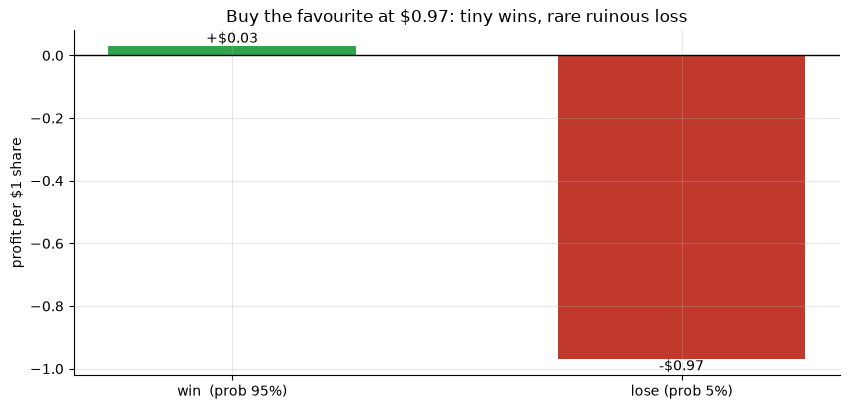

EV per $1 staked at p=0.97: -0.023  (need w>p just to break even; here w≈p)


In [3]:
# What you win vs what you risk, buying the favourite at its real price p
p = 0.97; w = R['w70']/100
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(['win  (prob %.0f%%)' % (w*100), 'lose (prob %.0f%%)' % ((1-w)*100)],
       [(1-p), -p], color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('profit per $1 share')
ax.set_title('Buy the favourite at $0.97: tiny wins, rare ruinous loss')
for i,(v,t) in enumerate([((1-p),'+$%.2f'%(1-p)), (-p,'-$%.2f'%p)]):
    ax.annotate(t,(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'EV per $1 staked at p={p}: {(w-p)/p:+.3f}  (need w>p just to break even; here w≈p)')

There it is. Win and you gain **3 cents**; lose and you give back **97**. At ~95% that averages to roughly **nothing** — and after the spread and fees, a little less than nothing. One loss erases ~30 wins. **The momentum was real; the market already owns it.**

## 5 · The verdict

- **Signal — Real.** A fresh \$70 move genuinely predicts the close (~95%, vastly better than a coin). No asterisk: the effect is there.
- **Tradability — Mirage.** The favoured side is priced at its true odds (\$0.95–0.99). You pay full freight; net of the spread the edge is **≤ 0**.
- **Get rich quick? — Busted.** \$300→\$14,000 is a martingale's lucky survivor, not a repeatable strategy (next beat shows the odds).

## 6 · Could you actually trade it? — play the dream out

Take the pitch at its word: bet **half your stack** each round on the favourite, and — generously — assume the game is a *fair* coin (you pay exactly the true odds, so you lose nothing to the house). Start at \$300, aim for \$14,000. Do it 200,000 times.

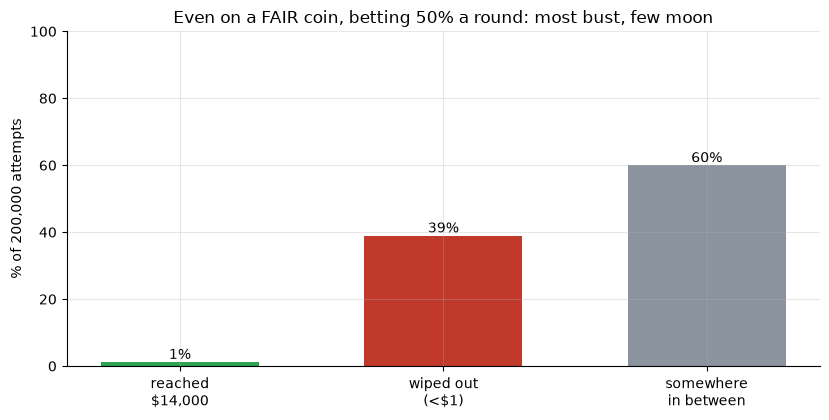

reached $14k: 1.2%   wiped out: 38.9%   median end: $4


In [4]:
m = st.monte_carlo(R['w70']/100, round(R['w70']/100,3), frac=0.50)
labels = ['reached\n$14,000', 'wiped out\n(<$1)', 'somewhere\nin between']
vals = [m['p_target']*100, m['p_ruin']*100, 100-m['p_target']*100-m['p_ruin']*100]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(labels, vals, color=[GREEN, RED, GREY], width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('% of 200,000 attempts'); ax.set_ylim(0, 100)
ax.set_title('Even on a FAIR coin, betting 50% a round: most bust, few moon')
plt.tight_layout(); plt.show()
print(f"reached $14k: {m['p_target']*100:.1f}%   wiped out: {m['p_ruin']*100:.1f}%   median end: ${m['median']:.0f}")

Even with **zero house edge**, betting half your stack ruins **~40%** of players and lands only **~1%** at \$14,000; the median ending balance is **\$4**. The viral post is that lucky 1%. Add the real spread, and the ruin share climbs toward certainty. The honest version of the strategy isn't "let it run" — it's "don't."

## 7 · Going further 🚪

- **The same shape elsewhere.** [Study 301 — Triple-RSI](../../301-triple-rsi/) is the stock-market twin: a real "90% win-rate" that's the *exit's shape*, not an edge. High win-rate + negative expectancy is the signature of a dressed-up martingale.
- **Measure the price yourself.** The read-only `live_paper` capture in this study takes **no key and no money** — it only reads public quotes. Run it for a week and watch the favoured ask sit at \$0.95–0.99.
- **The security angle.** A "free trading bot" whose order engine lives in a private repo and reads your wallet key is the real risk here — bigger than the bad EV.

*Think there's a \$0.80 favourite to be had on a decided market? Capture the live asks and show one — then check whether that cheap price wasn't just an honestly uncertain outcome all along.*